# Introduction

Customer churn affects revenue, planning, and customer lifetime value for banks. This project builds a model to identify which customers are likely to exit. The model uses a mix of microeconomic factors at the customer level and macroeconomic indicators that influence financial behavior.

The workflow follows four phases:

1. **Environment and data setup**

   * Create the project environment by importing relevan libraries.
   * Load and inspect the dataset.
   * Clean data and handle missing values.

2. **Feature engineering**

   * Prepare variables for modeling.
   * Encode categorical data.
   * Scale or transform features where needed.

3. **Model training**

   * Train machine learning models on the prepared data.
   * Tune hyperparameters and validate performance.

4. **Evaluation**

   * Measure model performance using suitable metrics.
   * Compare results and assess how well the model identifies churn risk.

The goal is to produce a reliable model that supports early identification of customers at risk of leaving. This supports targeted retention strategies and improved decision making. 


## Setting up the environment 

In [14]:
# Importing necessary libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

#convert date of birth to age
from datetime import datetime
from dateutil.relativedelta import relativedelta

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function for creating model pipelines - sklearn
from sklearn.pipeline import make_pipeline

# Function for creating model pipelines - imblearn
from imblearn.pipeline import make_pipeline as imbl_pipe

# Over-sampling using SMOTE
from imblearn.over_sampling import SMOTENC

# Visualisations 
import matplotlib.pyplot as plt
import seaborn as sns
 
#Exporting and importing models
import joblib

#### Processing data
The dataset is preprocessed and loaded for training and  testing. This includes;
1. Data Loading from excel
2. data separation into features and lables
3. Train-Validation Split
 

In [2]:
data = pd.read_excel('../data/botswana_bank_customer_churn.xlsx')
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115640 entries, 0 to 115639
Data columns (total 19 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Date of Birth                    115640 non-null  datetime64[ns]
 1   Gender                           115640 non-null  object        
 2   Marital Status                   115640 non-null  object        
 3   Number of Dependents             115640 non-null  int64         
 4   Occupation                       115640 non-null  object        
 5   Income                           115640 non-null  float64       
 6   Education Level                  115640 non-null  object        
 7   Customer Tenure                  115640 non-null  int64         
 8   Customer Segment                 115640 non-null  object        
 9   Preferred Communication Channel  115640 non-null  object        
 10  Credit Score                     115640 non-

In [3]:
#convert date of birth to age, rename Churn flag and remove unnecessary columns 
data['Date of Birth'] = pd.to_datetime(data['Date of Birth'])
data ["Age"] = data ['Date of Birth'].apply(lambda x: relativedelta(datetime.now(), x).years)
data.drop(['Date of Birth','Occupation','Churn Date','Churn Reason'], axis = 1, inplace = True)
data.rename({'Churn Flag': 'Churn'}, axis= 1, inplace= True)

In [4]:
float_col = data.select_dtypes(include=['float64']).columns.tolist()

for col in float_col:
    data_desciption =round(data[col].describe(),2)
    print (data_desciption)

print (round(data['NumComplaints'].describe(),2))

count    115640.00
mean      52641.36
std       27429.76
min        5000.96
25%       28857.07
50%       52658.11
75%       76364.16
max       99999.51
Name: Income, dtype: float64
count    115640.00
mean      25502.73
std       14127.86
min        1000.43
25%       13226.06
50%       25505.28
75%       37742.25
max       49999.69
Name: Outstanding Loans, dtype: float64
count    115640.00
mean     124639.21
std       72210.48
min           1.06
25%       61991.92
50%      124505.89
75%      187122.92
max      249998.91
Name: Balance, dtype: float64
count    115640.00
mean          4.99
std           3.16
min           0.00
25%           2.00
50%           5.00
75%           8.00
max          10.00
Name: NumComplaints, dtype: float64


| Percentile | Income (ZAR) | SA Socio-Economic Class | FNB Banking Segment |
|------------|--------------|--------------------------|---------------------|
| Min | R5,000 | Working Class / Lower-Middle | FNB Easy / Aspire |
| 25% | R28,857 | Upper-Middle Class | FNB Premier |
| 50% (Median) | R52,658 | Upper-Middle Class | FNB Premier |
| 75% | R76,364 | Upper-Middle / Emerging Affluent | FNB Premier / Private |
| Max | R99,999 | High-Income / Affluent | FNB Private Wealth |

Most of my data falls within the upper middle class sector. This information will influence how Micro_Stress_Squeeze is calculated.

In [5]:
# Constants for 2026 South African Scenario
REPO_HIKE = 0.01  # 1% Interest rate increase
INFLATION = 0.05  # 5% CPI/Inflation

# Calculation
data['Micro_Stress_Squeeze'] = (
    (data['Outstanding Loans'] * REPO_HIKE) + 
    (data['Income'] * 0.3 * INFLATION * (1 + data['Number of Dependents'] * 0.1))
) / data['Income']

## Micro_Stress_Squeeze Calculation

- **Loan impact:** `Outstanding Loans * REPO_HIKE` The repo rate hike (REPO_HIKE = 0.01) represents a 1% increase in borrowing costs. Multiplying it by the individual's outstanding loans estimates the additional financial burden caused by higher interest payments.

- **Inflation impact:** `Income * 0.3 * INFLATION * (1 + Number of Dependents * 0.1)`  
  - Empirical observations suggest that, for middle-class households, roughly 50% of income goes toward necessary expenditures. Of this, only 30% is sensitive to inflationary changes such as CPI increases. Hence the multiplication by 0.3 * INFLATION. 
  - More dependents increase financial stress. Each additional dependent increases the effective inflationary impact by 10%. 
  
- **Normalization:** Divide by `Income` to express stress as a share of income.

In [6]:
# Higher score = More stress/Less buffer
data['Liquidity_Stress'] = (
    data['Outstanding Loans'] / (data['Balance'] + 1) # +1 to avoid division by zero
) * (1 / (data['Credit History Length'] + 1))

In [7]:

# Create a binary "High Stress" flag (1 = High Stress, 0 = Normal)
data['High_Stress_Flag'] = np.where(
    (data['Income'] < data['Income'].quantile(0.25)) & 
    (data['Outstanding Loans'] > data['Outstanding Loans'].quantile(0.25)) & 
    (data['NumComplaints'] > data['NumComplaints'].quantile(0.25)), 
    1, 0
)

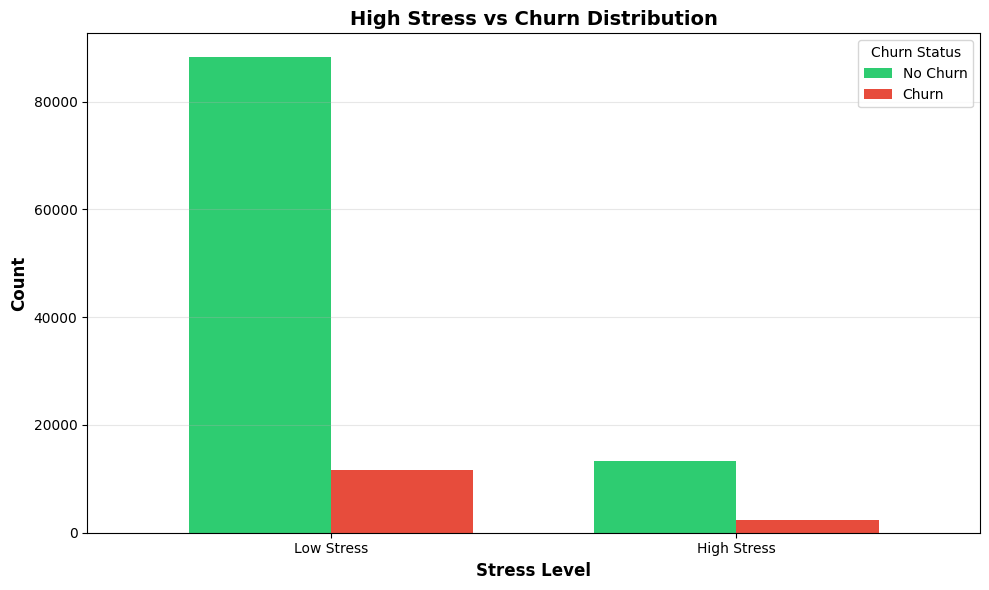

Crosstab - High Stress Flag vs Churn:
Churn                 0      1
High_Stress_Flag              
0                 88281  11733
1                 13265   2361

Percentage Distribution:
Churn                     0          1
High_Stress_Flag                      
0                 88.268642  11.731358
1                 84.890567  15.109433


In [ ]:
# Create a grouped bar chart: High Stress vs Churn
fig, ax = plt.subplots(figsize=(10, 6))

# Create crosstab to count combinations
stress_churn = pd.crosstab(data['High_Stress_Flag'], data['Churn'])

# Create grouped bar chart
stress_churn.plot(kind='bar', ax=ax, width=0.7, color=['#2ecc71', '#e74c3c'])

# Customize the plot
ax.set_xlabel('Stress Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('High Stress vs Churn Distribution', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Low Stress', 'High Stress'], rotation=0)
ax.legend(['No Churn', 'Churn'], title='Churn Status', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Crosstab - High Stress Flag vs Churn:")
print(stress_churn)
print("\nPercentage Distribution:")
print(pd.crosstab(data['High_Stress_Flag'], data['Churn'], normalize='index') * 100)

## Notable observations 

**Skewed Distribution Implications for Modeling**

Since both stress and churn are skewed, standard metrics like accuracy may be misleading. Will use ROC-AUC when evaluating predictive models.

**Churn in Low-Stress Segment**

There are still some churned customers in the low-stress group. This indicates that stress is not the only factor driving churn—other variables likely contribute.

**Retention Opportunities**

Most high-stress customers are not churned. This group is at risk, and proactive retention efforts could be effective.

In [8]:
catergorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print (catergorical_cols)
continuous_cols= [col for col in data.columns if col not in catergorical_cols]

['Gender', 'Marital Status', 'Education Level', 'Customer Segment', 'Preferred Communication Channel']


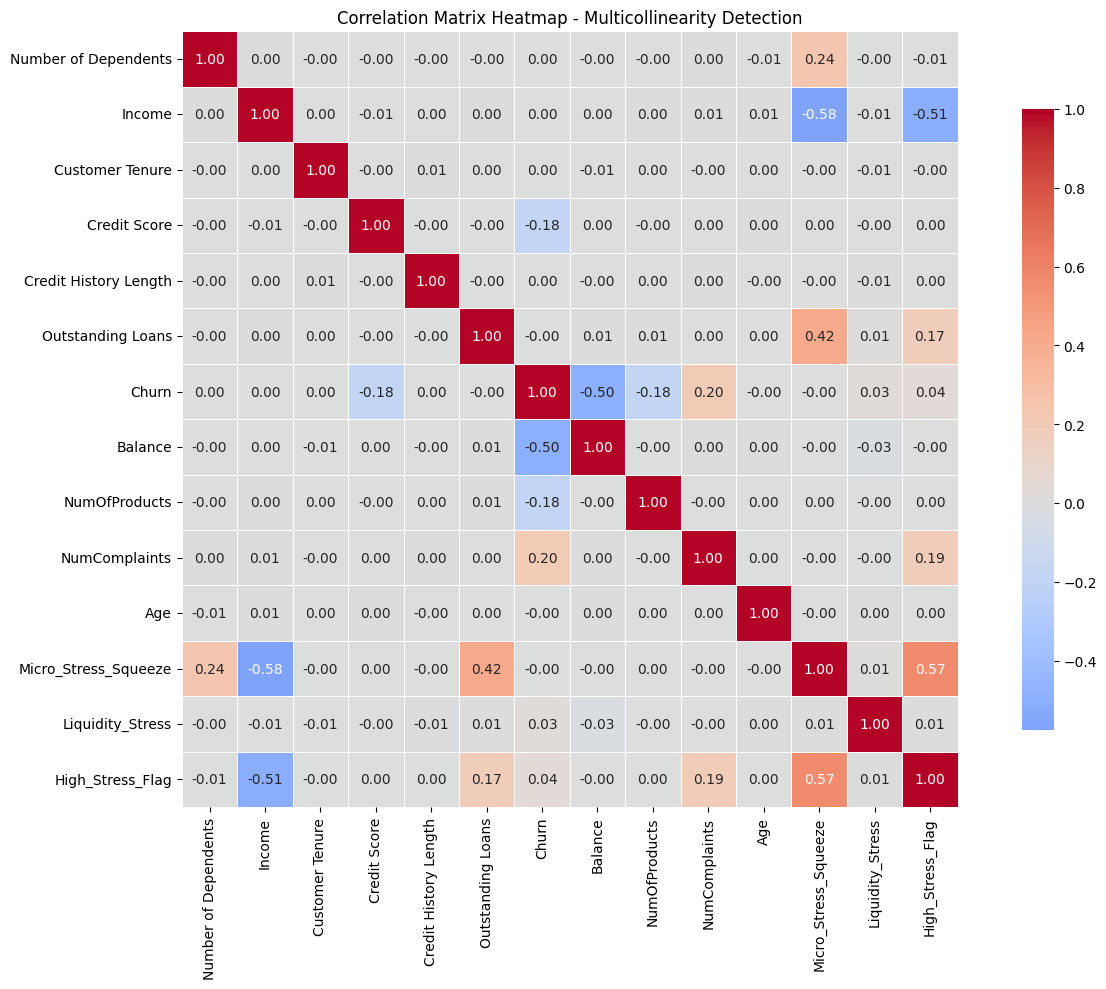

In [ ]:
# Correlation heatmap for multicollinearity detection
correlation_matrix = data[continuous_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap - Multicollinearity Detection')
plt.tight_layout()
plt.show()

There is low correlation between the predictors, which mean there is less redundant information.

In [9]:
## Encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

# Label Encoding
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
#data['Churned'] = le.fit_transform(data['Churned'])

# One-Hot Encoding
data_encoded = pd.get_dummies(data[['Marital Status','Customer Segment', 'Preferred Communication Channel']])
data = pd.concat([data.drop(['Marital Status','Customer Segment', 'Preferred Communication Channel'], axis=1), data_encoded], axis=1)
#Ordinal Encoding
ordinal_encoder = OrdinalEncoder(categories=[['High School', "Master's", "Bachelor's", 'Diploma']])
data['Education Level'] = ordinal_encoder.fit_transform(data[['Education Level']])

In [10]:

dummy_cols = ['Customer Segment_Corporate', 'Customer Segment_Retail', 'Customer Segment_SME','Preferred Communication Channel_Email', 'Preferred Communication Channel_Phone','Marital Status_Divorced', 'Marital Status_Married', 'Marital Status_Single']

for col in dummy_cols:
    data[col] = data[col].apply(lambda x: 1 if x == True else 0)

data.head()   

,Gender,Number of Dependents,Income,Education Level,Customer Tenure,Credit Score,Credit History Length,Outstanding Loans,Churn,Balance,...,Liquidity_Stress,High_Stress_Flag,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Customer Segment_Corporate,Customer Segment_Retail,Customer Segment_SME,Preferred Communication Channel_Email,Preferred Communication Channel_Phone
0,1,3,77710.14,0.0,30,397,24,41959.74,0,211359.05,...,0.007941,0,1,0,0,0,1,0,0,1
1,0,1,58209.87,0.0,27,665,10,8916.67,0,30624.76,...,0.026468,0,0,1,0,0,0,1,1,0
2,0,1,9794.01,0.0,14,715,21,43270.54,0,111956.61,...,0.017568,1,0,0,1,0,1,0,1,0
3,0,5,15088.98,0.0,23,747,17,17887.65,0,201187.61,...,0.004939,0,1,0,0,1,0,0,0,1
4,0,2,60726.56,1.0,22,549,25,32686.84,0,60391.24,...,0.020817,0,1,0,0,1,0,0,1,0


In [11]:
#Splitting the data into features and labels
y_data = data['Churn']
x_data = data.drop('Churn', axis=1)

In [12]:
#split the data into training and testing sets

random_state = 32

# Split X and y into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data,
                                                    test_size=0.3,
                                                    random_state=random_state,
                                                    stratify=y_data)

# Print number of observations in X_train, X_test, y_train, and y_test
print(len(x_train), len(x_test), len(y_train), len(y_test))

80948 34692 80948 34692


## Model training

I will use a pipeline to train my model and will apply grid search to optimize the model hyperparameters.

Within the pipeline, I use SMOTENC to handle class imbalance between churned and not churned, since the data contains a mix of:

    - Nominal features
    - Categorical features
    - Continuous features

I will use a random forest classifier for predictions because there is no clear pattern showing which features are most strongly related to churn.
This approach is guided by insights from my T-SNE visualization.

In [ ]:
# Import classifier
from sklearn.ensemble import RandomForestClassifier

# Define model with pipeline
model = imbl_pipe(SMOTENC(categorical_features=catergorical_cols,sampling_strategy='auto', random_state=random_state ),
                  RandomForestClassifier())

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('randomforestclassifier', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'randomforestclassifier__n_estimators': [200, 400, 600],
    'randomforestclassifier__max_depth': [None, 10, 20, 30],
    'randomforestclassifier__max_features': ['sqrt', 0.33],
    'randomforestclassifier__min_samples_split': [5, 10, 30],
    'randomforestclassifier__min_samples_leaf': [10, 30, 40],
    'randomforestclassifier__bootstrap': [True]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    pipeline,           # pass pipeline not raw model
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

In [ ]:
print(x_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 80948 entries, 42377 to 87455
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 80948 non-null  int64  
 1   Number of Dependents                   80948 non-null  int64  
 2   Income                                 80948 non-null  float64
 3   Education Level                        80948 non-null  float64
 4   Customer Tenure                        80948 non-null  int64  
 5   Credit Score                           80948 non-null  int64  
 6   Credit History Length                  80948 non-null  int64  
 7   Outstanding Loans                      80948 non-null  float64
 8   Balance                                80948 non-null  float64
 9   NumOfProducts                          80948 non-null  int64  
 10  NumComplaints                          80948 non-null  int64  
 11  Age

In [ ]:
print("Fitting the model this might take a while... ")
grid_search.fit(x_train, y_train)
print("Fitting complete")

Fitting the model this might take a while... 
Fitting 3 folds for each of 216 candidates, totalling 648 fits
Fitting complete


In [ ]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'randomforestclassifier__bootstrap': True, 'randomforestclassifier__max_depth': None, 'randomforestclassifier__max_features': 0.33, 'randomforestclassifier__min_samples_leaf': 10, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 400}
0.9980594961692669


## Evaluation

Grid Search Results Summary:
   bootstrap max_depth max_features  min_samples_leaf  min_samples_split  \
0       True      None         sqrt                10                  5   
1       True      None         sqrt                10                  5   
2       True      None         sqrt                10                  5   
3       True      None         sqrt                10                 10   
4       True      None         sqrt                10                 10   
5       True      None         sqrt                10                 10   
6       True      None         sqrt                10                 30   
7       True      None         sqrt                10                 30   
8       True      None         sqrt                10                 30   
9       True      None         sqrt                30                  5   

   n_estimators  mean_test_score  std_test_score  rank_test_score  
0           200         0.995867        0.000639              117 

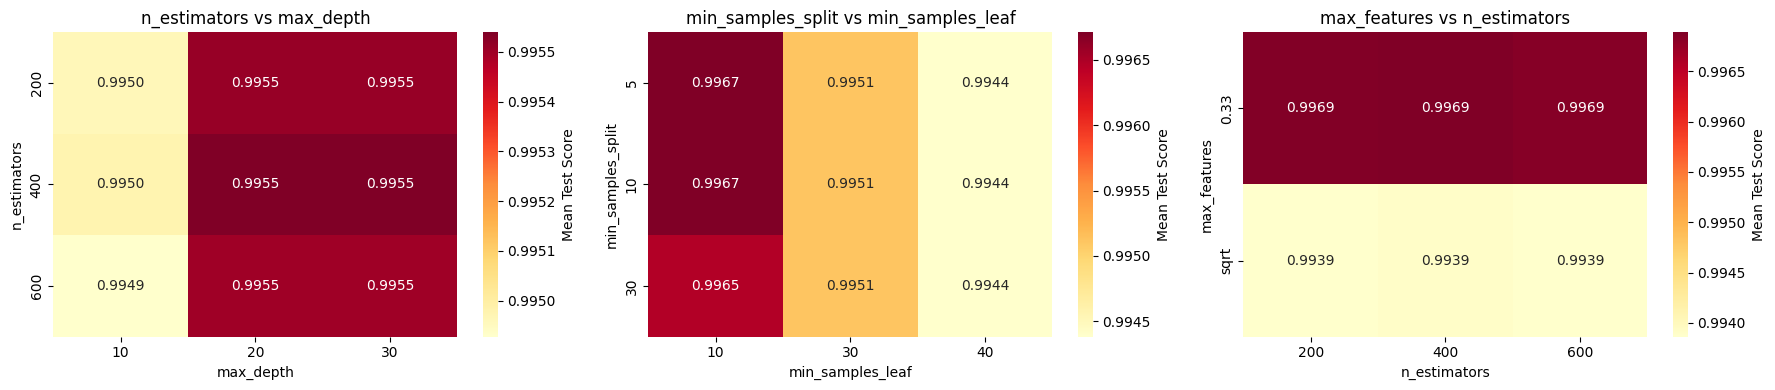


Top 10 Hyperparameter Combinations by Mean Test Score
     n_estimators max_depth max_features  min_samples_split  min_samples_leaf  mean_test_score  std_test_score
28            400      None         0.33                  5                10         0.998059        0.000274
31            400      None         0.33                 10                10         0.998059        0.000274
136           400        20         0.33                  5                10         0.998059        0.000274
139           400        20         0.33                 10                10         0.998059        0.000274
190           400        30         0.33                  5                10         0.998059        0.000274
193           400        30         0.33                 10                10         0.998059        0.000274
137           600        20         0.33                  5                10         0.998032        0.000278
140           600        20         0.33                 

In [ ]:
# Create pivot tables for hyperparameter combinations
# Extract grid search results into a DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Select relevant columns for analysis
param_cols = [col for col in results_df.columns if col.startswith('param_')]
metric_cols = ['mean_test_score', 'std_test_score', 'rank_test_score']

# Create a subset with parameters and metrics
results_summary = results_df[param_cols + metric_cols].copy()

# Rename columns for readability (remove 'param_' prefix)
results_summary.columns = [col.replace('param_randomforestclassifier__', '').replace('param_', '') for col in results_summary.columns]

print("Grid Search Results Summary:")
print(results_summary.head(10))
print(f"\nTotal combinations tested: {len(results_summary)}")

# Pivot table 1: n_estimators vs max_depth
pivot1 = results_summary.pivot_table(
    values='mean_test_score',
    index='n_estimators',
    columns='max_depth',
    aggfunc='mean'
)
print("\n" + "="*60)
print("Pivot Table 1: Mean Test Score by n_estimators and max_depth")
print("="*60)
print(pivot1.round(4))

# Pivot table 2: min_samples_split vs min_samples_leaf
pivot2 = results_summary.pivot_table(
    values='mean_test_score',
    index='min_samples_split',
    columns='min_samples_leaf',
    aggfunc='mean'
)
print("\n" + "="*60)
print("Pivot Table 2: Mean Test Score by min_samples_split and min_samples_leaf")
print("="*60)
print(pivot2.round(4))

# Pivot table 3: max_features vs n_estimators
pivot3 = results_summary.pivot_table(
    values='mean_test_score',
    index='max_features',
    columns='n_estimators',
    aggfunc='mean'
)
print("\n" + "="*60)
print("Pivot Table 3: Mean Test Score by max_features and n_estimators")
print("="*60)
print(pivot3.round(4))

# Visualize the pivot tables as heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.heatmap(pivot1, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Mean Test Score'})
axes[0].set_title('n_estimators vs max_depth')

sns.heatmap(pivot2, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Mean Test Score'})
axes[1].set_title('min_samples_split vs min_samples_leaf')

sns.heatmap(pivot3, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[2], cbar_kws={'label': 'Mean Test Score'})
axes[2].set_title('max_features vs n_estimators')

plt.tight_layout()
plt.show()

# Top 10 parameter combinations
print("\n" + "="*60)
print("Top 10 Hyperparameter Combinations by Mean Test Score")
print("="*60)
top_10 = results_summary.nlargest(10, 'mean_test_score')[['n_estimators', 'max_depth', 'max_features', 
                                                            'min_samples_split', 'min_samples_leaf', 
                                                            'mean_test_score', 'std_test_score']]
print(top_10.to_string())

### Notable take aways

There is high and stable performance across almost all hyperparameter combinations. The scores range roughly between 0.9939 and 0.9969.

The extremely high scores (0.99+) and the lack of sensitivity to most parameters could indicate data leakage or an imbalanced dataset where the model is simply predicting the majority class very well. Therefore will check confusion matrix to ensure the model is truly learning the underlying patterns.

In [17]:
final_score = grid_search.score(x_test, y_test)
print(f"Final test score: {final_score}")

predictions = grid_search.predict(x_test)
print(f"First 10 Predictions:   {predictions[:10]}")
print(f"First 10 Actual labels: {y_test[:10].tolist()}")

NameError: name 'grid_search' is not defined

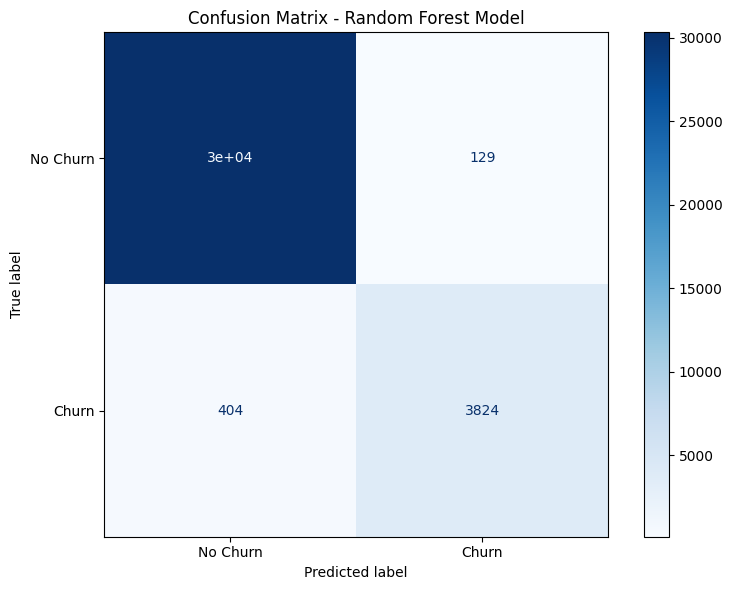

[[30335   129]
 [  404  3824]]


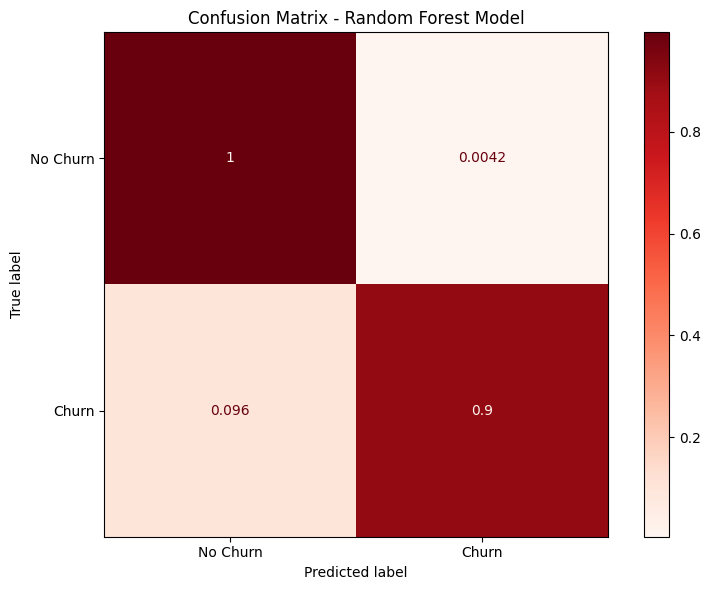

In [ ]:
# Make predictions on test set
y_pred = grid_search.predict(x_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Random Forest Model')
plt.tight_layout()
plt.show()

print (cm)

cm = np.around(cm / cm.sum(axis=1)[:, np.newaxis], 4)
 
# Display confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Reds')
plt.title('Confusion Matrix - Random Forest Model')
plt.tight_layout()
plt.show()

The confusion matrix shows that the model correctly predicts nearly 100% of non-churn cases and 90% of churn cases. Misclassifications are low, with 0.42% false positives and 9.6% false negatives. Overall, the model performs well.

In [ ]:
filename = '../output/macro_random_forest1.sav'
joblib.dump(grid_search, filename)

['macro_random_forest1.sav']

In [ ]:
# Load the saved model and calculate metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the saved model
filename = '../output/macro_random_forest1.sav'
loaded_model = joblib.load(filename)

# Make predictions on test data
y_pred = loaded_model.predict(x_test)

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.9674
Recall: 0.9044
F1 Score: 0.9348


### Notable take aways 

Precision (0.9674) – When the model predicts a customer will churn, it is correct 96.74% of the time.

Recall (0.9044) – The model identifies 90.44% of actual churn cases. This means about 9.6% of real churners are not detected.Missed churners matter because these customers leave without intervention.


**Overall Project Conclusion**

This project demonstrates a well-performing churn prediction model with strong classification metrics:

    Precision: 96.74%
    Recall: 90.44%
    F1 Score: 93.48%

The model shows strong ability to detect churn while maintaining low false alarms. The confusion matrix indicates reliable performance across both churn and non-churn classes. This suggests the model successfully learned meaningful patterns within the synthetic dataset.

However, since the training data was synthetic and balanced, real-world performance must be validated using actual customer data. In practice, churn prediction problems often involve imbalanced classes, behavioral variability, and noise, which may reduce recall and alter precision.